# Medidas de variabilidad 

Práctica 4 · ENDIREH 2021 

**Objetivo:** calcular desviacion estandar, coeficiente de variacion (CV), rango e IQR del tiempo sin convivencia con la pareja, comparar los grupos del indicador de violencia y construir un boxplot con cuantiles ponderados.

Ejecuta las celdas en orden con el entorno **endireh**. Este notebook es independiente del de localizacion.

## 1. Configuración

In [2]:
from pathlib import Path
import sys
from html import escape

RUTA_PROYECTO = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config/rutas.py").is_file()),
    None,
)
if RUTA_PROYECTO is None:
    raise RuntimeError("Abre Jupyter desde la raíz del proyecto o notebooks/.")
if str(RUTA_PROYECTO) not in sys.path:
    sys.path.insert(0, str(RUTA_PROYECTO))

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Markdown
from config.rutas import (
    RUTA_ENDIREH_RENOMBRADO_CSV, RUTA_FIGURAS_PERSONA_1,
    RUTA_APORTE_PERSONA_1_MD, RUTA_BOXPLOT_PERSONA_1,
)
from src.statistics.descriptivas import VARIABLE, preparar_base, resumir_por_grupo
from src.visualization.persona_1 import histograma_ponderado, boxplot_ponderado

%matplotlib inline

def mostrar_tabla(tabla):
    """Presenta todas las filas, conservando la precisión completa en los CSV."""
    def formato(v):
        if v is None:
            return "—"
        if isinstance(v, float):
            return f"{v:.2f}"
        if isinstance(v, int):
            return f"{v:,}"
        return escape(str(v))
    encabezado = "".join(f"<th>{escape(c.replace('_', ' '))}</th>" for c in tabla.columns)
    filas = "".join("<tr>" + "".join(f"<td>{formato(v)}</td>" for v in row) + "</tr>" for row in tabla.rows())
    display(HTML(f'<div style="overflow-x:auto"><table><thead><tr>{encabezado}</tr></thead><tbody>{filas}</tbody></table></div>'))

RUTA_FIGURAS_PERSONA_1.mkdir(parents=True, exist_ok=True)
print(f"Entrada: {RUTA_ENDIREH_RENOMBRADO_CSV.name}")

Entrada: endireh_2021_renombrado.csv
NumPy: 2.5.3; Polars: 1.44.2


## 2. Variable, universo y cobertura

Analizamos **`anios_sin_convivencia_pareja`**, expresada en años: tiempo transcurrido desde que se dejo de vivir con la pareja. Es el nombre corregido de `edad_primer_union`; **no mide la edad de la primera unión**. La correspondencia está documentada en el notebook de ajuste. Para esta variable, los cuestionarios compatibles son **A2, B1 y B2**.

Para la Practica 4 se recuperaron los codigos validos de 0 a 9 desde la misma fuente, despues de comprobar su correspondencia fila a fila con el CSV limpio. La Practica 3 se conserva. Los codigos 98 («no se acuerda») y 99 («no especificado») permanecen nulos; los nulos fuera del universo son distintos de los faltantes dentro de el.

**El codigo 0 significa menos de un año, no ausencia exacta de tiempo.** Para los calculos se conserva la codificacion recibida, sin asignar meses no observados. La media y el CV describen esa escala de años codificados y tienen una precision limitada para los tiempos inferiores a un año. En A2 puede tratarse de ausencia temporal de la pareja y en B2 de tiempo desde su fallecimiento; no todos los registros representan una ruptura.

Se muestran el total disponible y los grupos del indicador `sufrio_violencia_pareja` (0 y 1).

In [5]:
if not RUTA_ENDIREH_RENOMBRADO_CSV.is_file():
    raise FileNotFoundError("Ejecuta primero ajuste_columnas_practica_4.ipynb para generar la entrada.")
datos = pl.read_csv(RUTA_ENDIREH_RENOMBRADO_CSV, infer_schema_length=None)
base, cobertura = preparar_base(datos)
mostrar_tabla(cobertura)

grupo,n dataset,n universo a2 b1 b2,n disponibles,n faltantes en universo,porcentaje disponible dataset,porcentaje disponible universo
Total disponible,"110,127","24,560","23,677",883,21.50,96.40
No reporto violencia,"90,821","15,843","15,210",633,16.75,96.00
Reporto violencia,"19,306","8,717","8,467",250,43.86,97.13


## 3. Criterios y formulas

Usamos mdidas descriptivas de la distribución ponderada:

$$\sigma_w^2=\frac{\sum_i w_i(x_i-\bar{x}_w)^2}{\sum_i w_i},\qquad
\sigma_w=\sqrt{\sigma_w^2},\qquad CV_w=100\frac{\sigma_w}{\bar{x}_w}.$$

La varianza utiliza el divisor suma de pesos; con pesos unitarios usa $n$. Esta convención describe la distribución y no estima la incertidumbre de una encuesta compleja. La varianza se expresa en años², la desviación en años y el CV en porcentaje; el CV requiere una media positiva. El tiempo es una variable de razón con cero interpretable, (0 representa un intervalo menor de un año en esta codificación).

$$IQR_w=Q_w(0.75)-Q_w(0.25),\qquad R=\max(x)-\min(x).$$

Los cuartiles se calculan con la inversa de la CDF ponderada, sin interpolacion, igual que en localizacion. El rango utiliza los extremos observados: ponderar no cambia esos extremos si todos los pesos son positivos. El IQR es menos sensible que el rango a valores alejados del centro, y se calcula incluyendo los tiempos recientes recuperados.

No se aplica una etiqueta universal de dispersión «alta» o «baja» al CV: se interpreta su magnitud respecto a la media y se comparan grupos con la misma variable y metodo. 


In [7]:
variabilidad = resumir_por_grupo(base, "variabilidad")
mostrar_tabla(variabilidad.select("grupo", "ponderacion", "n", "minimo", "maximo", "rango", "varianza", "desviacion_estandar", "cv_porcentaje", "q1", "q3", "iqr"))

# Contraste independiente del CV sin ponderar con SciPy.
from scipy import stats
cv_scipy = 100 * float(stats.variation(base[VARIABLE].to_numpy(), ddof=0))
cv_propio = variabilidad.filter((pl.col("grupo") == "Total disponible") & (pl.col("ponderacion") == "Sin ponderar"))["cv_porcentaje"][0]
np.testing.assert_allclose(cv_propio, cv_scipy, rtol=1e-12)


grupo,ponderacion,n,minimo,maximo,rango,varianza,desviacion estandar,cv porcentaje,q1,q3,iqr
Total disponible,Sin ponderar,"23,677",0.00,76.00,76.00,114.89,10.72,106.91,2.00,15.00,13.00
Total disponible,Factor de expansión,"23,677",0.00,76.00,76.00,110.60,10.52,108.42,2.00,15.00,13.00
No reporto violencia,Sin ponderar,"15,210",0.00,76.00,76.00,117.33,10.83,108.03,2.00,15.00,13.00
No reporto violencia,Factor de expansión,"15,210",0.00,76.00,76.00,112.84,10.62,108.77,2.00,15.00,13.00
Reporto violencia,Sin ponderar,"8,467",0.00,72.00,72.00,110.51,10.51,104.86,2.00,15.00,13.00
Reporto violencia,Factor de expansión,"8,467",0.00,72.00,72.00,106.61,10.33,107.74,2.00,15.00,13.00


## 4. Interpretación de la variabilidad

La desviación estándar ponderada es 10.52 años: equivale al 108.42 % de la media. El IQR es 13 años, con Q1 = 2 y Q3 = 15; estos cuartiles delimitan la parte central de la distribución ponderada. Con años enteros puede haber acumulaciones de observaciones en sus límites. Los extremos son 0 y 76 años (rango de 76 años), lo que muestra por qué el rango y el IQR aportan información distinta.

El CV sin ponderar del total es 106.91 %. Por grupos, el CV ponderado es 108.77 % sin violencia reportada y 107.74 % con violencia reportada: diferencia de -1.03 puntos porcentuales. Los IQR son 13 y 13 años, respectivamente. El CV puede superar 100 %: la desviación es mayor que la media en esta escala codificada. Esto no es un porcentaje de mujeres ni una probabilidad de violencia. No se ha calculado incertidumbre ni probado una diferencia estadísticca.

## 5. Boxplot ponderado

Un boxplot ordinario ignoraria el factor de expansion. Aquí se construyen sus componentes de forma explicita: caja Q1–Q3 y mediana ponderadas; triangulo en la media ponderada; bigotes en los valores observados dentro de Q1 − 1.5 × IQR y Q3 + 1.5 × IQR. Los puntos muestran valores distintos fuera de los bigotes, sin representar cuantas observaciones o cuanto peso tienen.

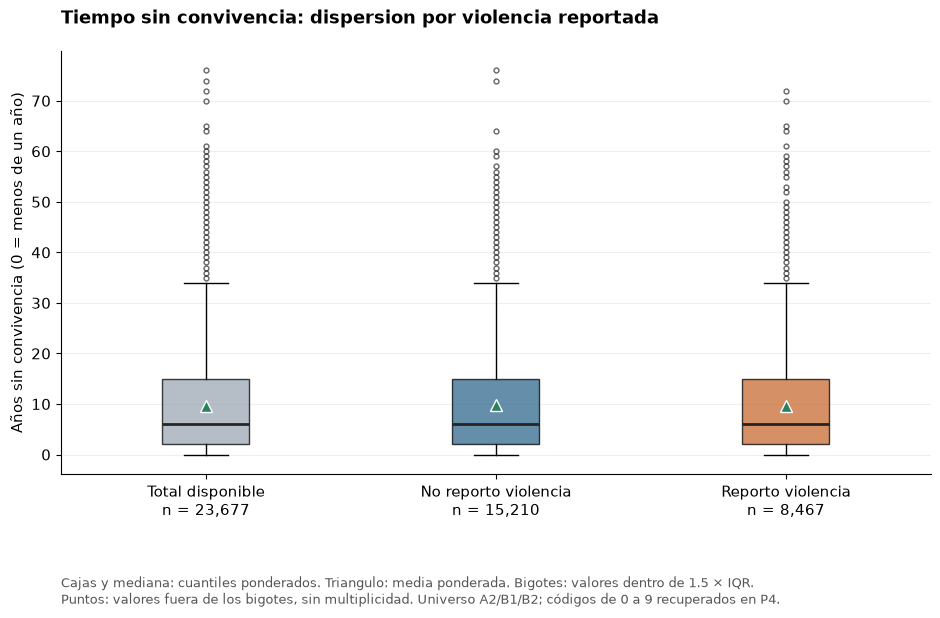

In [10]:
figura = boxplot_ponderado(base)
figura.savefig(RUTA_BOXPLOT_PERSONA_1, dpi=300, facecolor="white")
plt.show()
plt.close(figura)

Las cajas muestran una amplia superposición en este subconjunto. Sus componentes son:

Total disponible: mediana = 6, Q1 = 2 y Q3 = 15 años.
No reportó violencia: mediana = 6, Q1 = 2 y Q3 = 15 años.
Reportó violencia: mediana = 6, Q1 = 2 y Q3 = 15 años.
Los valores superiores alejados de las cajas forman parte de la cola larga. Los puntos fuera de los bigotes no son errores confirmados ni indican mayor gravedad de violencia; se conservan. El código 0 representa menos de un año. No se calculan pruebas de igualdad ni efectos causales.

In [11]:
print(f"Figura exportada: {RUTA_BOXPLOT_PERSONA_1.relative_to(RUTA_PROYECTO)}")

Figura exportada: reports/persona_1/figuras/boxplot_ponderado.png
